### California Housing – modellering som beslutsunderlag

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [3]:
df = pd.read_csv('housing.csv')
df.describe()
print(df.shape)

(20640, 10)


In [4]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [5]:
threshold = df["median_house_value"].quantile(0.8)
df["high_value"] = (df["median_house_value"] >= threshold).astype(int)
X = df.drop(["median_house_value", "high_value"], axis=1)
y = df["high_value"]

feature_column_names = X.columns
target_column_name = "high_value"

X_full = X
y_full = y

print('X shape', X.shape)
print('y shape', y.shape)

print('\nKlassfördelning (hela datasetet):')
print(y.value_counts())

print('\nKlassfördelning i procent:')
print(y.value_counts(normalize= True))


X shape (20640, 9)
y shape (20640,)

Klassfördelning (hela datasetet):
high_value
0    16510
1     4130
Name: count, dtype: int64

Klassfördelning i procent:
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64


In [6]:
print(feature_column_names)

print(target_column_name)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')
high_value


In [7]:
print('Saknade värden(Hela datasetet)')
print(X.isna().sum().sort_values(ascending=False))
# Kolumnen total_bedrooms har 207 saknade värden och det kommer jag hantera senare en median Imputer för att minska påverkan av extrema värden.
print(X.describe())

Saknade värden(Hela datasetet)
total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  
count    20433.

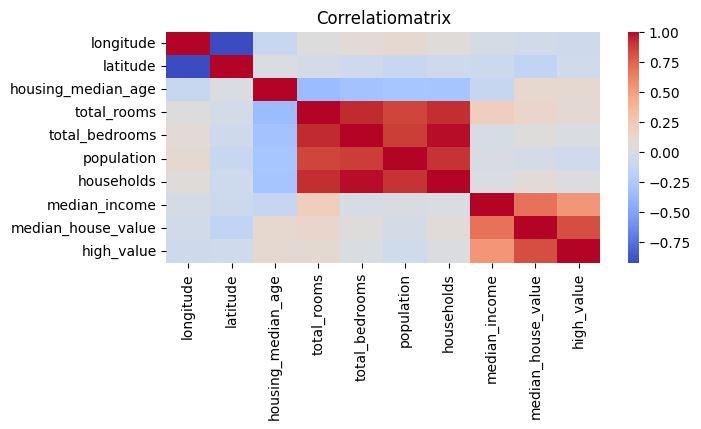

In [8]:
plt.figure(figsize=(7,3))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.title('Correlatiomatrix')
plt.show()

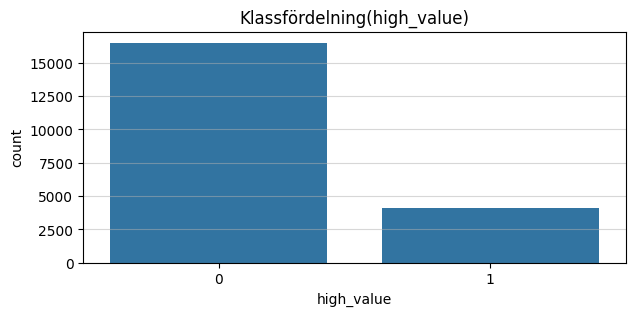

In [9]:
plt.figure(figsize=(7,3))
plt.title("Klassfördelning(high_value)")
sns.countplot(x=y)
plt.grid(axis="y", alpha= 0.5)
plt.show()


In [10]:
X_train, X_test, y_train, y_test = train_test_split( 
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)
print('\nKlassfördelning (TRAIN):')
print(y_train.value_counts())

(16512, 9) (16512,)

Klassfördelning (TRAIN):
high_value
0    13208
1     3304
Name: count, dtype: int64


In [11]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

C:\Users\janek\AppData\Local\Temp\ipykernel_9392\2836064378.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


In [12]:
baseline_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
f1_score(y_test,y_pred)

0.6913073237508556

In [13]:
numeric_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_pipeline_tree, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [14]:

logreg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

dt_pipeline = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', RandomForestClassifier(random_state=42))
])


models = {
    'LogisticRegression': logreg_pipeline,
    'DecisionTree': dt_pipeline,
    'RandomForest': rf_pipeline

}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = f1_score(y_test, y_pred)


results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1'])
results_df

,F1
LogisticRegression,0.691307
DecisionTree,0.703364
RandomForest,0.761204


In [26]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_results = {}
for name, model in models.items():
    scores= cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    cv_results[name] = {
        'Mean F1': scores.mean(),
        'Std F1': scores.std()
}

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.sort_values('Mean F1', ascending=False)
display(cv_results_df)

,Mean F1,Std F1
LogisticRegression,0.696216,0.020765
DecisionTree,0.707427,0.007255
RandomForest,0.785160,0.019325


In [27]:
cv_results_df['Best Score'] = (
    cv_results_df['Mean F1'] - cv_results_df['Std F1']
)
best_model_name = cv_results_df['Best Score'].idxmax()
best_model = models[best_model_name]
best_model_name


'RandomForest'